In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('eda.csv')
df

,price,year,mileage,city,seller,lattitude,longitude,population,temperature,air_quality,...,salary,infrastructure,class,drive,gearbox,fuel_type,engine_volume,engine_power,brand,model
0,2070000,2022,49900.0,Москва,GROMOV IMPORT,55.750446,37.617494,17125000.0,7.49,2.0,...,362722.15,500.0,Лифтбек,Передний привод,Автомат,бензин,1.4,150.0,Skoda,Octavia IV (A8)
1,953700,2018,158735.0,Москва,АО Банк Инго,55.750446,37.617494,17125000.0,7.49,2.0,...,362722.15,500.0,Седан,Передний привод,Автомат,бензин,1.6,123.0,Hyundai,Solaris II
2,550000,2007,220000.0,Москва,Irvineflora,55.750446,37.617494,17125000.0,7.49,2.0,...,362722.15,500.0,Внедорожник 5 дв.,Полный привод,Автомат,бензин,4.8,355.0,BMW,X5 48i II (E70)
3,200000,2006,150000.0,Москва,петр л.,55.750446,37.617494,17125000.0,7.49,2.0,...,362722.15,500.0,Седан,Передний привод,Механика,бензин,1.6,81.0,Lada,(ВАЗ) Kalina I
4,610000,2012,189500.0,Москва,Частное лицо,55.750446,37.617494,17125000.0,7.49,2.0,...,362722.15,500.0,Седан,Передний привод,Механика,бензин,1.6,109.0,Chevrolet,Cruze I
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10767,2021400,2026,0.0,Петрозаводск,Петрозаводск-Лада,61.790039,34.390007,278551.0,8.05,2.0,...,53460.00,194.0,Универсал 5 дв.,Передний привод,Механика,бензин,1.8,122.0,Lada,(ВАЗ) Vesta SW Cross I Рестайлинг (NG)
10768,1890000,2026,0.0,Петрозаводск,Петрозаводск-Лада,61.790039,34.390007,278551.0,8.05,2.0,...,53460.00,194.0,Универсал 5 дв.,Передний привод,Механика,бензин,1.6,106.0,Lada,(ВАЗ) Vesta SW Cross I Рестайлинг (NG)
10769,1341600,2026,0.0,Петрозаводск,Петрозаводск-Лада,61.790039,34.390007,278551.0,8.05,2.0,...,53460.00,194.0,Универсал 5 дв.,Передний привод,Механика,бензин,1.6,90.0,Lada,(ВАЗ) Largus I Рестайлинг
10770,2742000,2022,34000.0,Псков,Станислав Игоревич,57.817392,28.334346,209840.0,10.99,3.0,...,60032.50,192.0,Внедорожник 5 дв.,Передний привод,Механика,бензин,1.5,150.0,Volkswagen,Tiguan Allspace II Рестайлинг


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10772 entries, 0 to 10771
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           10772 non-null  int64  
 1   year            10772 non-null  int64  
 2   mileage         10772 non-null  float64
 3   city            10772 non-null  object 
 4   seller          10772 non-null  object 
 5   lattitude       10772 non-null  float64
 6   longitude       10772 non-null  float64
 7   population      10772 non-null  float64
 8   temperature     10772 non-null  float64
 9   air_quality     10772 non-null  float64
 10  mestnost        10772 non-null  float64
 11  salary          10772 non-null  float64
 12  infrastructure  10772 non-null  float64
 13  class           10772 non-null  object 
 14  drive           10772 non-null  object 
 15  gearbox         10772 non-null  object 
 16  fuel_type       10772 non-null  object 
 17  engine_volume   10687 non-null 

In [5]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


documentation for catboost: https://catboost.ai/docs/en/concepts/python-reference_catboost_fit

In [6]:
y = df['price']
x = df.drop(columns=['price'])
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=777)
feat = ['city', 'seller', 'class', 'drive', 'gearbox', 'fuel_type', 'brand', 'model']
from catboost import CatBoostRegressor
pred = CatBoostRegressor(iterations=1000, learning_rate=0.1, random_seed=777)
pred.fit(x_train, y_train, cat_features=feat, eval_set=(x_test, y_test))
preds = pred.predict(x_test)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, preds)
print(mae)

0:	learn: 1404952.3960415	test: 1426321.3958418	best: 1426321.3958418 (0)	total: 71.9ms	remaining: 1m 11s
1:	learn: 1311892.8482476	test: 1332924.3066358	best: 1332924.3066358 (1)	total: 92.4ms	remaining: 46.1s
2:	learn: 1231126.7459502	test: 1252837.9212811	best: 1252837.9212811 (2)	total: 116ms	remaining: 38.7s
3:	learn: 1155759.5542683	test: 1178545.5485667	best: 1178545.5485667 (3)	total: 136ms	remaining: 33.8s
4:	learn: 1090898.9809398	test: 1114823.3488513	best: 1114823.3488513 (4)	total: 155ms	remaining: 30.9s
5:	learn: 1031995.2142946	test: 1055602.9963716	best: 1055602.9963716 (5)	total: 176ms	remaining: 29.2s
6:	learn: 980772.6907330	test: 1004206.9089091	best: 1004206.9089091 (6)	total: 198ms	remaining: 28.1s
7:	learn: 934320.3645896	test: 956251.2175319	best: 956251.2175319 (7)	total: 221ms	remaining: 27.4s
8:	learn: 897152.5673627	test: 919750.9754243	best: 919750.9754243 (8)	total: 241ms	remaining: 26.5s
9:	learn: 859267.6347000	test: 881728.4075004	best: 881728.4075004 (

In [7]:
most_important = pred.get_feature_importance(prettified=True)
most_important

,Feature Id,Importances
0,engine_power,27.989907
1,year,26.730412
2,mileage,10.444421
3,brand,9.679962
4,drive,4.839171
5,engine_volume,4.772457
6,gearbox,4.003750
7,fuel_type,3.394306
8,class,2.715435
9,model,1.925470


In [11]:
most_important.columns = ['Features', 'Influence level, %']
most_important

,Features,"Influence level, %"
0,engine_power,27.989907
1,year,26.730412
2,mileage,10.444421
3,brand,9.679962
4,drive,4.839171
5,engine_volume,4.772457
6,gearbox,4.003750
7,fuel_type,3.394306
8,class,2.715435
9,model,1.925470


/tmp/ipykernel_351/1577196892.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Influence level, %', y='Features', data=most_important, palette='magma')


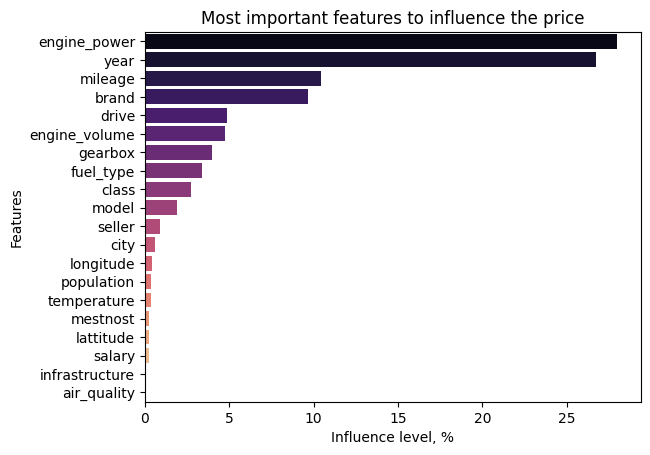

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x='Influence level, %', y='Features', data=most_important, palette='magma')
plt.title('Most important features to influence the price')
plt.show()

In [16]:
y = df['price']
x = df.drop(columns=['price'])
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=777)
feat = ['city', 'seller', 'class', 'drive', 'gearbox', 'fuel_type', 'brand', 'model']
from catboost import CatBoostRegressor
lrs = [0.01, 0.05, 0.1, 0.15, 0.2]
res = []
for elem in lrs:
  for j in range(100, 1000, 100):
    pred2 = CatBoostRegressor(iterations=j, learning_rate=elem, random_seed=777)
    pred2.fit(x_train, y_train, cat_features=feat, eval_set=(x_test, y_test))
    preds2 = pred2.predict(x_test)
    from sklearn.metrics import mean_absolute_error
    mae = mean_absolute_error(y_test, preds2)
    res.append({'learning_rate': elem, 'iterations': j, 'mae': mae})

Выходные данные были обрезаны до нескольких последних строк (5000).
447:	learn: 316072.3364274	test: 426848.8461203	best: 426238.8380500 (436)	total: 10.5s	remaining: 10.6s
448:	learn: 315994.4944349	test: 426811.5141582	best: 426238.8380500 (436)	total: 10.5s	remaining: 10.6s
449:	learn: 315827.7075917	test: 426758.0396245	best: 426238.8380500 (436)	total: 10.5s	remaining: 10.5s
450:	learn: 315789.0916660	test: 426753.2068258	best: 426238.8380500 (436)	total: 10.6s	remaining: 10.5s
451:	learn: 315692.1652402	test: 426705.0913987	best: 426238.8380500 (436)	total: 10.6s	remaining: 10.5s
452:	learn: 315629.9693971	test: 426728.6896361	best: 426238.8380500 (436)	total: 10.6s	remaining: 10.5s
453:	learn: 315568.8251334	test: 426589.4373683	best: 426238.8380500 (436)	total: 10.6s	remaining: 10.4s
454:	learn: 315375.4878528	test: 426668.2877362	best: 426238.8380500 (436)	total: 10.6s	remaining: 10.4s
455:	learn: 315304.8815689	test: 426646.5701285	best: 426238.8380500 (436)	total: 10.7s	rema

In [17]:
df2 = pd.DataFrame(res)
df2

,learning_rate,iterations,mae
0,0.01,100,649513.428185
1,0.01,200,476180.605076
2,0.01,300,407144.847896
3,0.01,400,376719.923840
4,0.01,500,360665.291654
5,0.01,600,351525.770648
6,0.01,700,343842.105608
7,0.01,800,338035.832665
8,0.01,900,332257.693163
9,0.05,100,370195.925539


In [18]:
best = df2.sort_values('mae').iloc[0]
best_lr = best['learning_rate']
best_iter = best['iterations']
best_mae = best['mae']

In [19]:
pred3 = CatBoostRegressor(iterations=best_iter, learning_rate=best_lr, random_seed=777)
pred3.fit(x_train, y_train, cat_features=feat, eval_set=(x_test, y_test))
preds3 = pred3.predict(x_test)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, preds3)

0:	learn: 1404952.3960415	test: 1426321.3958418	best: 1426321.3958418 (0)	total: 27.6ms	remaining: 24.9s
1:	learn: 1311892.8482476	test: 1332924.3066358	best: 1332924.3066358 (1)	total: 45.8ms	remaining: 20.6s
2:	learn: 1231126.7459502	test: 1252837.9212811	best: 1252837.9212811 (2)	total: 68.2ms	remaining: 20.4s
3:	learn: 1155759.5542683	test: 1178545.5485667	best: 1178545.5485667 (3)	total: 87ms	remaining: 19.5s
4:	learn: 1090898.9809398	test: 1114823.3488513	best: 1114823.3488513 (4)	total: 107ms	remaining: 19.1s
5:	learn: 1031995.2142946	test: 1055602.9963716	best: 1055602.9963716 (5)	total: 127ms	remaining: 18.9s
6:	learn: 980772.6907330	test: 1004206.9089091	best: 1004206.9089091 (6)	total: 149ms	remaining: 19s
7:	learn: 934320.3645896	test: 956251.2175319	best: 956251.2175319 (7)	total: 173ms	remaining: 19.3s
8:	learn: 897152.5673627	test: 919750.9754243	best: 919750.9754243 (8)	total: 193ms	remaining: 19.1s
9:	learn: 859267.6347000	test: 881728.4075004	best: 881728.4075004 (9)	

In [20]:
gucci = pred3.get_feature_importance(prettified=True)

In [21]:
gucci.columns = ['Features', 'Influence level, %']

/tmp/ipykernel_351/2647112229.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Influence level, %', y='Features', data=gucci, palette='magma')


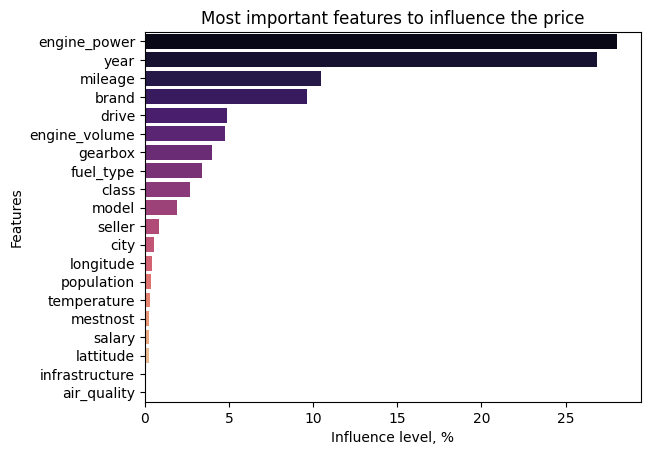

In [22]:
sns.barplot(x='Influence level, %', y='Features', data=gucci, palette='magma')
plt.title('Most important features to influence the price')
plt.show()

In [23]:
print(best_iter)
print(best_lr)
print(best_mae)

900.0
0.1
281942.7234059096
